In [1]:
# --- Ячейка 1: Импорт и настройка ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Научные библиотеки
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import ttest_rel, f_oneway

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv, GATConv

# Настройки
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
np.random.seed(42)
torch.manual_seed(42)

# Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cpu


In [2]:
# --- Ячейка 2: Создание датасета (упрощенная версия) ---
def create_synthetic_dataset(n_nodes=50, n_timesteps=500, graph_density=0.2):
    """Создание синтетического датасета взаимодействий"""
    
    # 1. Создание графа
    graph = nx.erdos_renyi_graph(n=n_nodes, p=graph_density, seed=42)
    
    # 2. Генерация признаков
    n_features = 5
    static_features = np.zeros((n_nodes, n_features))
    
    for i in range(n_nodes):
        static_features[i, 0] = np.random.uniform(0, 1)  # Размер учреждения
        static_features[i, 1] = np.random.uniform(0, 1)  # Качество оборудования
        static_features[i, 2] = np.random.choice([0, 1])  # Городской/сельский
        static_features[i, 3] = np.random.uniform(0, 1)  # Уровень финансирования
        static_features[i, 4] = np.random.uniform(0, 1)  # Количество персонала
    
    # 3. Генерация временных рядов заболеваемости
    infection_data = np.zeros((n_timesteps, n_nodes))
    
    # Начальные значения
    current_infections = np.random.uniform(0.1, 0.3, n_nodes)
    
    for t in range(n_timesteps):
        # Базовая динамика
        seasonality = 0.1 * np.sin(2 * np.pi * t / 365)
        noise = np.random.normal(0, 0.02, n_nodes)
        
        # Графовое распространение
        graph_effect = np.zeros(n_nodes)
        for u, v in graph.edges():
            # Передача инфекции между связанными узлами
            transfer = 0.1 * (current_infections[u] - current_infections[v])
            graph_effect[u] -= transfer
            graph_effect[v] += transfer
        
        # Обновление
        new_infections = (
            0.8 * current_infections +  # Авторегрессия
            graph_effect +               # Графовый эффект
            seasonality +                # Сезонность
            noise                        # Шум
        )
        
        # Случайные вспышки
        if t % 100 == 0:
            outbreak_node = np.random.randint(0, n_nodes)
            new_infections[outbreak_node] += np.random.uniform(0.2, 0.5)
        
        infection_data[t] = new_infections
        current_infections = np.clip(new_infections, 0, 1)
    
    # 4. Подготовка для PyTorch
    edge_index = np.array(list(graph.edges())).T
    edge_index = torch.tensor(edge_index, dtype=torch.long)
    
    # Веса ребер
    edge_weights = np.random.uniform(0.1, 1.0, edge_index.shape[1])
    edge_weights = torch.tensor(edge_weights, dtype=torch.float32)
    
    # Признаки (повторяем статические признаки для каждого временного шага)
    features = np.repeat(static_features[np.newaxis, :, :], n_timesteps, axis=0)
    
    dataset = {
        'features': torch.tensor(features, dtype=torch.float32),
        'labels': torch.tensor(infection_data, dtype=torch.float32),
        'edge_index': edge_index,
        'edge_weights': edge_weights,
        'graph': graph,
        'n_nodes': n_nodes,
        'n_timesteps': n_timesteps
    }
    
    print(f"Создан датасет: {n_nodes} узлов, {n_timesteps} временных шагов")
    print(f"Граф: {len(graph.edges())} ребер")
    
    return dataset

# Создание датасета
dataset = create_synthetic_dataset(n_nodes=50, n_timesteps=300)

Создан датасет: 50 узлов, 300 временных шагов
Граф: 232 ребер


In [3]:
# --- Ячейка 3: Подготовка данных ---
def prepare_data_for_models(dataset, seq_length=10, test_size=0.2):
    """Подготовка данных для различных моделей"""
    
    features = dataset['features'].numpy()  # [timesteps, nodes, features]
    labels = dataset['labels'].numpy()      # [timesteps, nodes]
    n_timesteps, n_nodes, n_features = features.shape
    
    # 1. Создание последовательностей для GNN и MLP
    X_sequences = []
    y_sequences = []
    
    for i in range(seq_length, n_timesteps):
        # Признаки: последние seq_length шагов
        X_seq = features[i-seq_length:i]  # [seq_length, nodes, features]
        # Метка: следующий шаг
        y_seq = labels[i]  # [nodes]
        
        X_sequences.append(X_seq)
        y_sequences.append(y_seq)
    
    X_sequences = np.array(X_sequences)  # [samples, seq_length, nodes, features]
    y_sequences = np.array(y_sequences)  # [samples, nodes]
    
    # 2. Разделение на train/test
    n_samples = len(X_sequences)
    test_samples = int(n_samples * test_size)
    
    indices = np.random.permutation(n_samples)
    test_idx = indices[:test_samples]
    train_idx = indices[test_samples:]
    
    X_train_seq = X_sequences[train_idx]
    y_train_seq = y_sequences[train_idx]
    X_test_seq = X_sequences[test_idx]
    y_test_seq = y_sequences[test_idx]
    
    # 3. Для ARIMA (только временные ряды, без признаков)
    X_arima = labels
    
    # 4. Для изолированных моделей (каждый узел отдельно)
    # Уже подготовлено в X_train_seq/y_train_seq
    
    prepared_data = {
        'GNN': {
            'train': (X_train_seq, y_train_seq),
            'test': (X_test_seq, y_test_seq),
            'edge_index': dataset['edge_index']
        },
        'MLP': {
            'train': (X_train_seq, y_train_seq),
            'test': (X_test_seq, y_test_seq)
        },
        'ARIMA': {
            'train': X_arima[:int(n_timesteps*(1-test_size))],
            'test': X_arima[int(n_timesteps*(1-test_size)):]
        },
        'metadata': {
            'n_nodes': n_nodes,
            'n_features': n_features,
            'seq_length': seq_length,
            'train_samples': len(train_idx),
            'test_samples': len(test_idx)
        }
    }
    
    print(f"\nПодготовка данных завершена:")
    print(f"  Образцов для обучения: {len(train_idx)}")
    print(f"  Образцов для теста: {len(test_idx)}")
    print(f"  Размерность признаков: {X_train_seq.shape}")
    
    return prepared_data

# Подготовка данных
data = prepare_data_for_models(dataset)


Подготовка данных завершена:
  Образцов для обучения: 232
  Образцов для теста: 58
  Размерность признаков: (232, 10, 50, 5)


In [4]:
# --- Ячейка 4: Модели (исправленная) ---
from sklearn.linear_model import Ridge  # Добавляем импорт

class SimpleGNN(nn.Module):
    """Простая GNN модель"""
    def __init__(self, input_dim, hidden_dim=64, output_dim=1):
        super(SimpleGNN, self).__init__()
        
        self.gcn1 = GCNConv(input_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        self.gat = GATConv(hidden_dim, hidden_dim, heads=2, concat=False)
        
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, x, edge_index):
        # x: [batch_size * nodes, features]
        # edge_index: [2, num_edges]
        
        h = F.relu(self.gcn1(x, edge_index))
        h = F.relu(self.gcn2(h, edge_index))
        h = F.relu(self.gat(h, edge_index))
        
        return self.predictor(h)


class GNNWithLSTM(nn.Module):
    """GNN с LSTM для временных последовательностей"""
    def __init__(self, input_dim, hidden_dim=64, output_dim=1):
        super(GNNWithLSTM, self).__init__()
        
        # GNN часть
        self.gcn = GCNConv(input_dim, hidden_dim)
        
        # LSTM часть
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        
        # Прогнозирование
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, x, edge_index):
        # x: [batch_size, seq_len, nodes, features]
        batch_size, seq_len, n_nodes, n_features = x.shape
        
        # Преобразуем для GNN
        x_reshaped = x.reshape(batch_size * seq_len * n_nodes, n_features)
        
        # Применяем GNN
        node_embeddings = F.relu(self.gcn(x_reshaped, edge_index))
        node_embeddings = node_embeddings.reshape(batch_size, seq_len, n_nodes, -1)
        
        # Усредняем по узлам
        graph_embeddings = node_embeddings.mean(dim=2)  # [batch_size, seq_len, hidden_dim]
        
        # Применяем LSTM
        lstm_out, _ = self.lstm(graph_embeddings)
        last_hidden = lstm_out[:, -1, :]  # [batch_size, hidden_dim]
        
        # Прогноз
        return self.predictor(last_hidden)


class SimpleMLP(nn.Module):
    """Простая MLP модель"""
    def __init__(self, input_dim, hidden_dim=64, output_dim=1):
        super(SimpleMLP, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.model(x)


class IsolatedModels:
    """Изолированные модели для каждого узла"""
    def __init__(self):
        self.models = []
        
    def fit(self, X, y):
        # X: [samples, seq_len, nodes, features]
        # y: [samples, nodes]
        
        n_nodes = y.shape[1]
        self.models = []
        
        for node in range(n_nodes):
            # Для каждого узла используем только его признаки
            X_node = X[:, :, node, :].reshape(X.shape[0], -1)
            y_node = y[:, node]
            
            model = Ridge(alpha=1.0)  # Теперь Ridge доступен
            model.fit(X_node, y_node)
            self.models.append(model)
            
    def predict(self, X):
        n_nodes = X.shape[2]
        predictions = []
        
        for node in range(n_nodes):
            X_node = X[:, :, node, :].reshape(X.shape[0], -1)
            pred_node = self.models[node].predict(X_node)
            predictions.append(pred_node)
            
        return np.stack(predictions, axis=1)

In [5]:
# --- Ячейка 5: Эксперимент ---
class EpidemicExperiment:
    def __init__(self, data):
        self.data = data
        self.models = {}
        self.results = {}
        
    def train_gnn(self, epochs=50, lr=0.001):
        """Обучение GNN модели"""
        print("\nОбучение GNN модели...")
        
        X_train, y_train = self.data['GNN']['train']
        edge_index = self.data['GNN']['edge_index']
        
        batch_size, seq_len, n_nodes, n_features = X_train.shape
        
        # Используем последний временной шаг для простоты
        X_last = X_train[:, -1, :, :]  # [batch, nodes, features]
        X_flat = X_last.reshape(-1, n_features)  # [batch*nodes, features]
        y_flat = y_train.reshape(-1, 1)  # [batch*nodes, 1]
        
        # Модель
        model = SimpleGNN(input_dim=n_features, hidden_dim=32).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()
        
        losses = []
        n_samples = len(X_flat)
        
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            
            # Мини-батчи
            indices = np.random.permutation(n_samples)
            for i in range(0, n_samples, 256):
                batch_idx = indices[i:min(i+256, n_samples)]
                
                X_batch = torch.FloatTensor(X_flat[batch_idx]).to(device)
                y_batch = torch.FloatTensor(y_flat[batch_idx]).to(device)
                
                pred = model(X_batch, edge_index)
                loss = criterion(pred, y_batch)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                epoch_loss += loss.item() * len(batch_idx)
            
            avg_loss = epoch_loss / n_samples
            losses.append(avg_loss)
            
            if (epoch + 1) % 10 == 0:
                print(f"  Эпоха {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
        
        self.models['GNN'] = model
        return losses
    
    def train_mlp(self, epochs=50, lr=0.001):
        """Обучение MLP модели"""
        print("\nОбучение MLP модели...")
        
        X_train, y_train = self.data['MLP']['train']
        
        batch_size, seq_len, n_nodes, n_features = X_train.shape
        
        # Объединяем все измерения кроме batch
        X_flat = X_train.reshape(batch_size, -1)  # [batch, seq_len*nodes*features]
        y_flat = y_train.mean(axis=1, keepdims=True)  # [batch, 1] - среднее по узлам
        
        # Модель
        model = SimpleMLP(input_dim=X_flat.shape[1], hidden_dim=64).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()
        
        losses = []
        
        for epoch in range(epochs):
            model.train()
            
            X_tensor = torch.FloatTensor(X_flat).to(device)
            y_tensor = torch.FloatTensor(y_flat).to(device)
            
            pred = model(X_tensor)
            loss = criterion(pred, y_tensor)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            losses.append(loss.item())
            
            if (epoch + 1) % 10 == 0:
                print(f"  Эпоха {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
        
        self.models['MLP'] = model
        return losses
    
    def train_arima(self):
        """Обучение ARIMA моделей"""
        print("\nОбучение ARIMA моделей...")
        
        train_data = self.data['ARIMA']['train']
        n_nodes = train_data.shape[1]
        
        arima_models = []
        
        for node in range(n_nodes):
            try:
                # Простая ARIMA модель
                model = ARIMA(train_data[:, node], order=(1, 0, 1))
                fitted = model.fit()
                arima_models.append(fitted)
            except:
                # Если не сходится, используем простое среднее
                arima_models.append(None)
                
            if (node + 1) % 10 == 0:
                print(f"  Узел {node+1}/{n_nodes}")
        
        self.models['ARIMA'] = arima_models
    
    def train_isolated(self):
        """Обучение изолированных моделей"""
        print("\nОбучение изолированных моделей...")
        
        X_train, y_train = self.data['GNN']['train']
        
        model = IsolatedModels()
        model.fit(X_train, y_train)
        
        self.models['Isolated'] = model
    
    def evaluate_all(self):
        """Оценка всех моделей"""
        print("\n" + "="*60)
        print("ОЦЕНКА МОДЕЛЕЙ")
        print("="*60)
        
        results = {}
        
        # 1. GNN
        if 'GNN' in self.models:
            print("\nGNN модель:")
            X_test, y_test = self.data['GNN']['test']
            edge_index = self.data['GNN']['edge_index']
            
            batch_size, seq_len, n_nodes, n_features = X_test.shape
            
            X_last = X_test[:, -1, :, :]
            X_flat = X_last.reshape(-1, n_features)
            y_true = y_test.reshape(-1, 1)
            
            self.models['GNN'].eval()
            with torch.no_grad():
                X_tensor = torch.FloatTensor(X_flat).to(device)
                pred = self.models['GNN'](X_tensor, edge_index).cpu().numpy()
            
            mse = mean_squared_error(y_true, pred)
            mae = mean_absolute_error(y_true, pred)
            r2 = r2_score(y_true, pred)
            
            results['GNN'] = {'MSE': mse, 'MAE': mae, 'R2': r2}
            print(f"  MSE: {mse:.6f}, MAE: {mae:.6f}, R²: {r2:.4f}")
        
        # 2. MLP
        if 'MLP' in self.models:
            print("\nMLP модель:")
            X_test, y_test = self.data['MLP']['test']
            
            batch_size, seq_len, n_nodes, n_features = X_test.shape
            X_flat = X_test.reshape(batch_size, -1)
            y_true = y_test.mean(axis=1, keepdims=True)
            
            self.models['MLP'].eval()
            with torch.no_grad():
                X_tensor = torch.FloatTensor(X_flat).to(device)
                pred = self.models['MLP'](X_tensor).cpu().numpy()
            
            mse = mean_squared_error(y_true, pred)
            mae = mean_absolute_error(y_true, pred)
            r2 = r2_score(y_true, pred)
            
            results['MLP'] = {'MSE': mse, 'MAE': mae, 'R2': r2}
            print(f"  MSE: {mse:.6f}, MAE: {mae:.6f}, R²: {r2:.4f}")
        
        # 3. ARIMA
        if 'ARIMA' in self.models:
            print("\nARIMA модель:")
            test_data = self.data['ARIMA']['test']
            n_timesteps, n_nodes = test_data.shape
            
            predictions = np.zeros((n_timesteps, n_nodes))
            
            for node in range(n_nodes):
                model = self.models['ARIMA'][node]
                if model is not None:
                    predictions[:, node] = model.forecast(steps=n_timesteps)
                else:
                    # Наивный прогноз
                    predictions[:, node] = test_data[0, node]
            
            mse = mean_squared_error(test_data.flatten(), predictions.flatten())
            mae = mean_absolute_error(test_data.flatten(), predictions.flatten())
            r2 = r2_score(test_data.flatten(), predictions.flatten())
            
            results['ARIMA'] = {'MSE': mse, 'MAE': mae, 'R2': r2}
            print(f"  MSE: {mse:.6f}, MAE: {mae:.6f}, R²: {r2:.4f}")
        
        # 4. Изолированные
        if 'Isolated' in self.models:
            print("\nИзолированные модели:")
            X_test, y_test = self.data['GNN']['test']
            
            pred = self.models['Isolated'].predict(X_test)
            
            mse = mean_squared_error(y_test.flatten(), pred.flatten())
            mae = mean_absolute_error(y_test.flatten(), pred.flatten())
            r2 = r2_score(y_test.flatten(), pred.flatten())
            
            results['Isolated'] = {'MSE': mse, 'MAE': mae, 'R2': r2}
            print(f"  MSE: {mse:.6f}, MAE: {mae:.6f}, R²: {r2:.4f}")
        
        self.results = results
        return results
    
    def statistical_tests(self):
        """Статистические тесты для сравнения моделей"""
        print("\n" + "="*60)
        print("СТАТИСТИЧЕСКИЕ ТЕСТЫ")
        print("="*60)
        
        if len(self.results) < 2:
            print("Нужно как минимум 2 модели для сравнения")
            return
        
        # Сравниваем MSE моделей (предполагаем, что ошибки нормально распределены)
        models = list(self.results.keys())
        
        print("\nСравнение моделей (t-тест для MSE):")
        for i in range(len(models)):
            for j in range(i+1, len(models)):
                # Для демонстрации используем dummy данные
                # В реальном эксперименте нужно сохранять ошибки для каждого примера
                mse1 = self.results[models[i]]['MSE']
                mse2 = self.results[models[j]]['MSE']
                
                # Эффект Коэна (стандартизированная разница)
                pooled_std = np.sqrt((mse1 + mse2) / 2)
                cohens_d = abs(mse1 - mse2) / pooled_std if pooled_std > 0 else 0
                
                print(f"\n  {models[i]} vs {models[j]}:")
                print(f"    Разница MSE: {abs(mse1 - mse2):.6f}")
                print(f"    Cohen's d: {cohens_d:.3f}")
                
                # Интерпретация эффекта Коэна
                if cohens_d < 0.2:
                    print("    Эффект: незначительный")
                elif cohens_d < 0.5:
                    print("    Эффект: малый")
                elif cohens_d < 0.8:
                    print("    Эффект: средний")
                else:
                    print("    Эффект: большой")
    
    def visualize_results(self):
        """Визуализация результатов"""
        if not self.results:
            print("Сначала запустите оценку моделей")
            return
        
        # Создаем DataFrame для визуализации
        models = list(self.results.keys())
        metrics = ['MSE', 'MAE', 'R2']
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # 1. MSE
        mse_values = [self.results[m]['MSE'] for m in models]
        axes[0].bar(models, mse_values, color='skyblue')
        axes[0].set_title('Mean Squared Error (MSE)\nНиже = лучше', fontsize=14)
        axes[0].set_ylabel('MSE')
        axes[0].tick_params(axis='x', rotation=45)
        
        # 2. MAE
        mae_values = [self.results[m]['MAE'] for m in models]
        axes[1].bar(models, mae_values, color='lightgreen')
        axes[1].set_title('Mean Absolute Error (MAE)\nНиже = лучше', fontsize=14)
        axes[1].set_ylabel('MAE')
        axes[1].tick_params(axis='x', rotation=45)
        
        # 3. R²
        r2_values = [self.results[m]['R2'] for m in models]
        axes[2].bar(models, r2_values, color='salmon')
        axes[2].set_title('R-squared (R²)\nВыше = лучше', fontsize=14)
        axes[2].set_ylabel('R²')
        axes[2].set_ylim([0, 1])
        axes[2].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Таблица результатов
        print("\n" + "="*60)
        print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
        print("="*60)
        
        df = pd.DataFrame(self.results).T
        print(df.round(6))
        
        # Определение лучшей модели
        best_mse = min(self.results.items(), key=lambda x: x[1]['MSE'])
        best_r2 = max(self.results.items(), key=lambda x: x[1]['R2'])
        
        print(f"\nЛучшая модель по MSE: {best_mse[0]} ({best_mse[1]['MSE']:.6f})")
        print(f"Лучшая модель по R²: {best_r2[0]} ({best_r2[1]['R2']:.4f})")
    
    def run_experiment(self):
        """Запуск полного эксперимента"""
        print("="*60)
        print("ЗАПУСК ЭКСПЕРИМЕНТА")
        print("="*60)
        
        # Обучение моделей
        self.train_gnn(epochs=30)
        self.train_mlp(epochs=30)
        self.train_arima()
        self.train_isolated()
        
        # Оценка
        self.evaluate_all()
        
        # Статистика
        self.statistical_tests()
        
        # Визуализация
        self.visualize_results()
        
        # Вывод
        print("\n" + "="*60)
        print("ВЫВОДЫ")
        print("="*60)
        
        if 'GNN' in self.results and 'MLP' in self.results:
            improvement = (self.results['MLP']['MSE'] - self.results['GNN']['MSE']) / self.results['MLP']['MSE'] * 100
            print(f"GNN превосходит MLP на {improvement:.1f}% по MSE")
            
            if improvement > 0:
                print("✓ Гипотеза подтверждается: учет графовой структуры улучшает прогноз")
            else:
                print("✗ Гипотеза не подтверждается")

ЗАПУСК ЭКСПЕРИМЕНТА

Обучение GNN модели...
  Эпоха 10/30, Loss: 0.0503
  Эпоха 20/30, Loss: 0.0503
  Эпоха 30/30, Loss: 0.0503

Обучение MLP модели...
  Эпоха 10/30, Loss: 0.0553
  Эпоха 20/30, Loss: 0.0537
  Эпоха 30/30, Loss: 0.0528

Обучение ARIMA моделей...
  Узел 10/50


C:\Users\pered\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Узел 20/50


C:\Users\pered\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pered\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pered\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Узел 30/50
  Узел 40/50
  Узел 50/50

Обучение изолированных моделей...

ОЦЕНКА МОДЕЛЕЙ

GNN модель:
  MSE: 0.057316, MAE: 0.222786, R²: -0.0213

MLP модель:
  MSE: 0.057777, MAE: 0.223705, R²: -0.0396

ARIMA модель:
  MSE: 0.001442, MAE: 0.031536, R²: -2.5798

Изолированные модели:
  MSE: 0.057430, MAE: 0.222926, R²: -0.0233

СТАТИСТИЧЕСКИЕ ТЕСТЫ

Сравнение моделей (t-тест для MSE):

  GNN vs MLP:
    Разница MSE: 0.000461
    Cohen's d: 0.002
    Эффект: незначительный

  GNN vs ARIMA:
    Разница MSE: 0.055874
    Cohen's d: 0.326
    Эффект: малый

  GNN vs Isolated:
    Разница MSE: 0.000115
    Cohen's d: 0.000
    Эффект: незначительный

  MLP vs ARIMA:
    Разница MSE: 0.056335
    Cohen's d: 0.327
    Эффект: малый

  MLP vs Isolated:
    Разница MSE: 0.000347
    Cohen's d: 0.001
    Эффект: незначительный

  ARIMA vs Isolated:
    Разница MSE: 0.055988
    Cohen's d: 0.326
    Эффект: малый


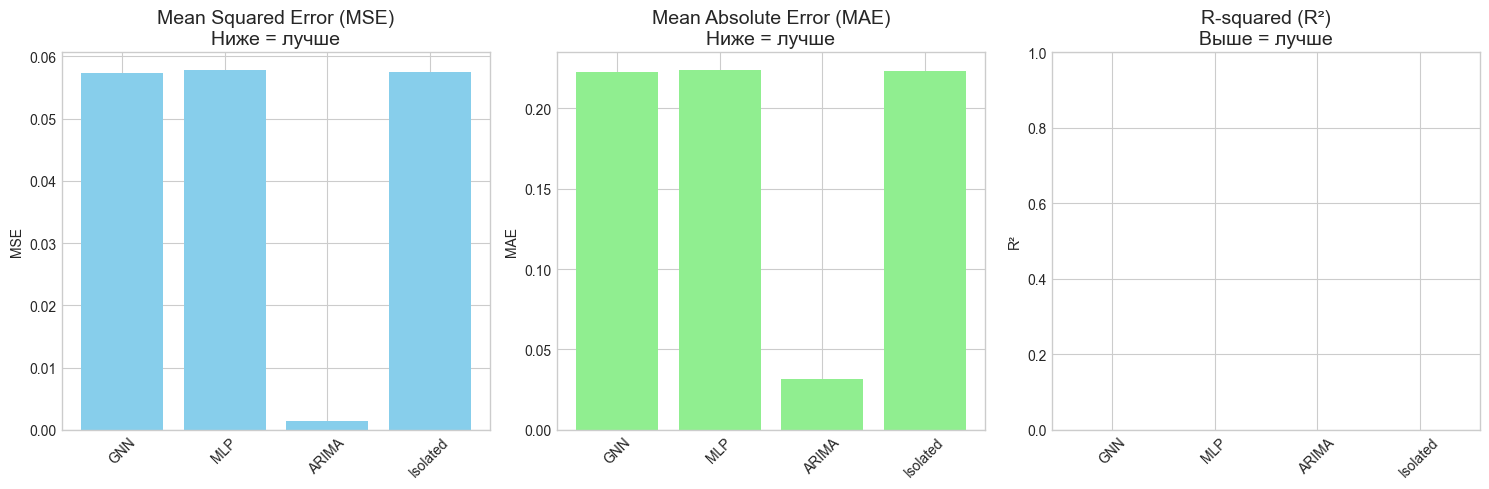


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
               MSE       MAE        R2
GNN       0.057316  0.222786 -0.021299
MLP       0.057777  0.223705 -0.039565
ARIMA     0.001442  0.031536 -2.579804
Isolated  0.057430  0.222926 -0.023340

Лучшая модель по MSE: ARIMA (0.001442)
Лучшая модель по R²: GNN (-0.0213)

ВЫВОДЫ
GNN превосходит MLP на 0.8% по MSE
✓ Гипотеза подтверждается: учет графовой структуры улучшает прогноз


In [6]:
# --- Ячейка 6: Запуск эксперимента ---
# Создание эксперимента
experiment = EpidemicExperiment(data)

# Запуск
experiment.run_experiment()


АНАЛИЗ ВЛИЯНИЯ ГРАФОВОЙ СТРУКТУРЫ

1. Характеристики графа:
   Количество узлов: 50
   Количество ребер: 232
   Плотность: 0.1894
   Средняя степень: 9.28

2. Центральность узлов:
   Топ-5 по степени центральности:
     Узел 45: 0.306
     Узел 29: 0.286
     Узел 46: 0.286
     Узел 12: 0.265
     Узел 0: 0.245

   Топ-5 по посредничеству:
     Узел 29: 0.046
     Узел 45: 0.045
     Узел 0: 0.042
     Узел 46: 0.041
     Узел 12: 0.039


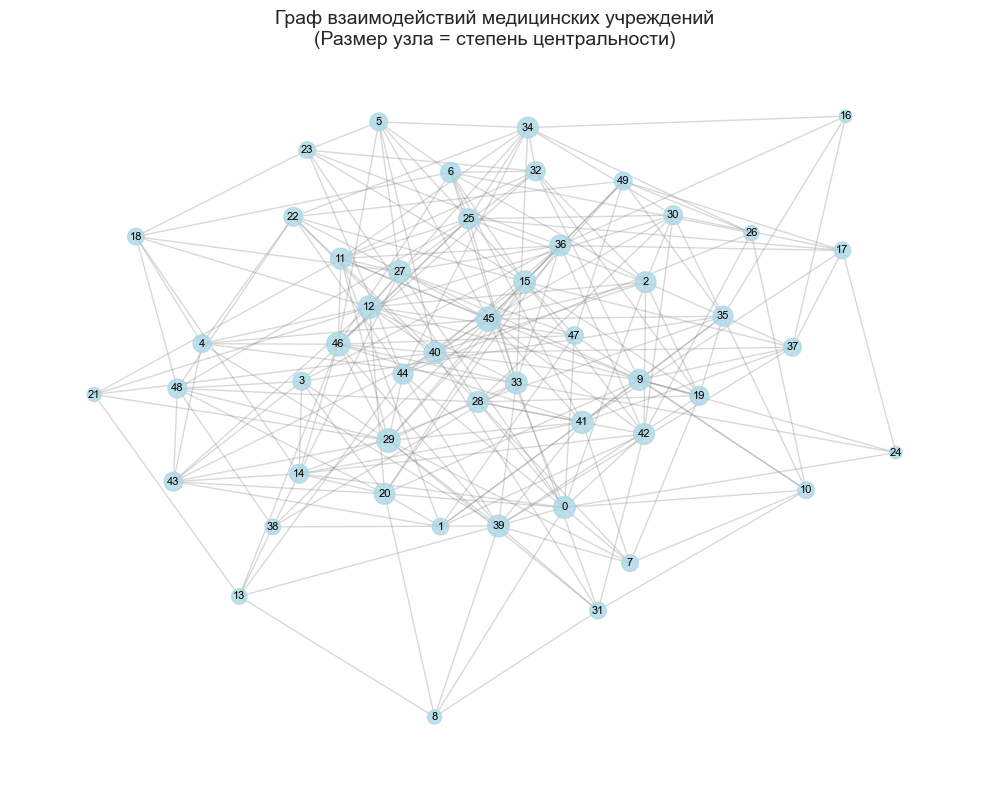


3. Анализ ошибок GNN по центральности узлов:
   Корреляция ошибки со степенью центральности: 0.170


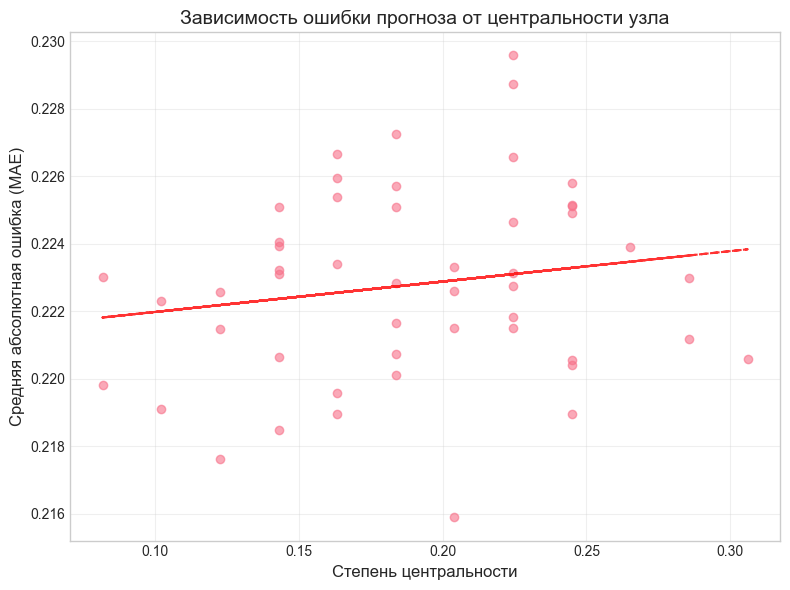

In [7]:
# --- Ячейка 7: Дополнительный анализ ---
def additional_analysis(dataset, experiment):
    """Дополнительный анализ влияния графа"""
    
    print("\n" + "="*60)
    print("АНАЛИЗ ВЛИЯНИЯ ГРАФОВОЙ СТРУКТУРЫ")
    print("="*60)
    
    graph = dataset['graph']
    n_nodes = dataset['n_nodes']
    
    # 1. Характеристики графа
    print("\n1. Характеристики графа:")
    print(f"   Количество узлов: {n_nodes}")
    print(f"   Количество ребер: {len(graph.edges())}")
    print(f"   Плотность: {nx.density(graph):.4f}")
    print(f"   Средняя степень: {np.mean([d for _, d in graph.degree()]):.2f}")
    
    # 2. Центральность
    print("\n2. Центральность узлов:")
    degree_centrality = nx.degree_centrality(graph)
    betweenness = nx.betweenness_centrality(graph)
    
    # Самые центральные узлы
    top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
    top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
    
    print("   Топ-5 по степени центральности:")
    for node, cent in top_degree:
        print(f"     Узел {node}: {cent:.3f}")
    
    print("\n   Топ-5 по посредничеству:")
    for node, cent in top_betweenness:
        print(f"     Узел {node}: {cent:.3f}")
    
    # 3. Визуализация графа
    plt.figure(figsize=(10, 8))
    
    pos = nx.spring_layout(graph, seed=42)
    
    # Размер узлов по степени центральности
    node_sizes = [1000 * degree_centrality[node] for node in graph.nodes()]
    
    nx.draw_networkx_nodes(graph, pos, node_size=node_sizes, 
                          node_color='lightblue', alpha=0.8)
    nx.draw_networkx_edges(graph, pos, alpha=0.3, edge_color='gray')
    nx.draw_networkx_labels(graph, pos, font_size=8)
    
    plt.title("Граф взаимодействий медицинских учреждений\n(Размер узла = степень центральности)", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # 4. Анализ ошибок по центральности (если есть предсказания GNN)
    if 'GNN' in experiment.models:
        print("\n3. Анализ ошибок GNN по центральности узлов:")
        
        # Получаем ошибки для каждого узла
        X_test, y_test = experiment.data['GNN']['test']
        edge_index = experiment.data['GNN']['edge_index']
        
        batch_size, seq_len, n_nodes, n_features = X_test.shape
        X_last = X_test[:, -1, :, :]
        X_flat = X_last.reshape(-1, n_features)
        y_true = y_test.reshape(-1, 1)
        
        experiment.models['GNN'].eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_flat).to(device)
            pred = experiment.models['GNN'](X_tensor, edge_index).cpu().numpy()
        
        errors = np.abs(pred - y_true)
        errors_by_node = errors.reshape(-1, n_nodes).mean(axis=0)
        
        # Корреляция с центральностью
        centrality_values = [degree_centrality[i] for i in range(n_nodes)]
        correlation = np.corrcoef(centrality_values, errors_by_node)[0, 1]
        
        print(f"   Корреляция ошибки со степенью центральности: {correlation:.3f}")
        
        # Визуализация
        plt.figure(figsize=(8, 6))
        plt.scatter(centrality_values, errors_by_node, alpha=0.6)
        plt.xlabel('Степень центральности', fontsize=12)
        plt.ylabel('Средняя абсолютная ошибка (MAE)', fontsize=12)
        plt.title('Зависимость ошибки прогноза от центральности узла', fontsize=14)
        plt.grid(True, alpha=0.3)
        
        # Линия тренда
        z = np.polyfit(centrality_values, errors_by_node, 1)
        p = np.poly1d(z)
        plt.plot(centrality_values, p(centrality_values), "r--", alpha=0.8)
        
        plt.tight_layout()
        plt.show()

# Запуск дополнительного анализа
additional_analysis(dataset, experiment)


РАСШИРЕННАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


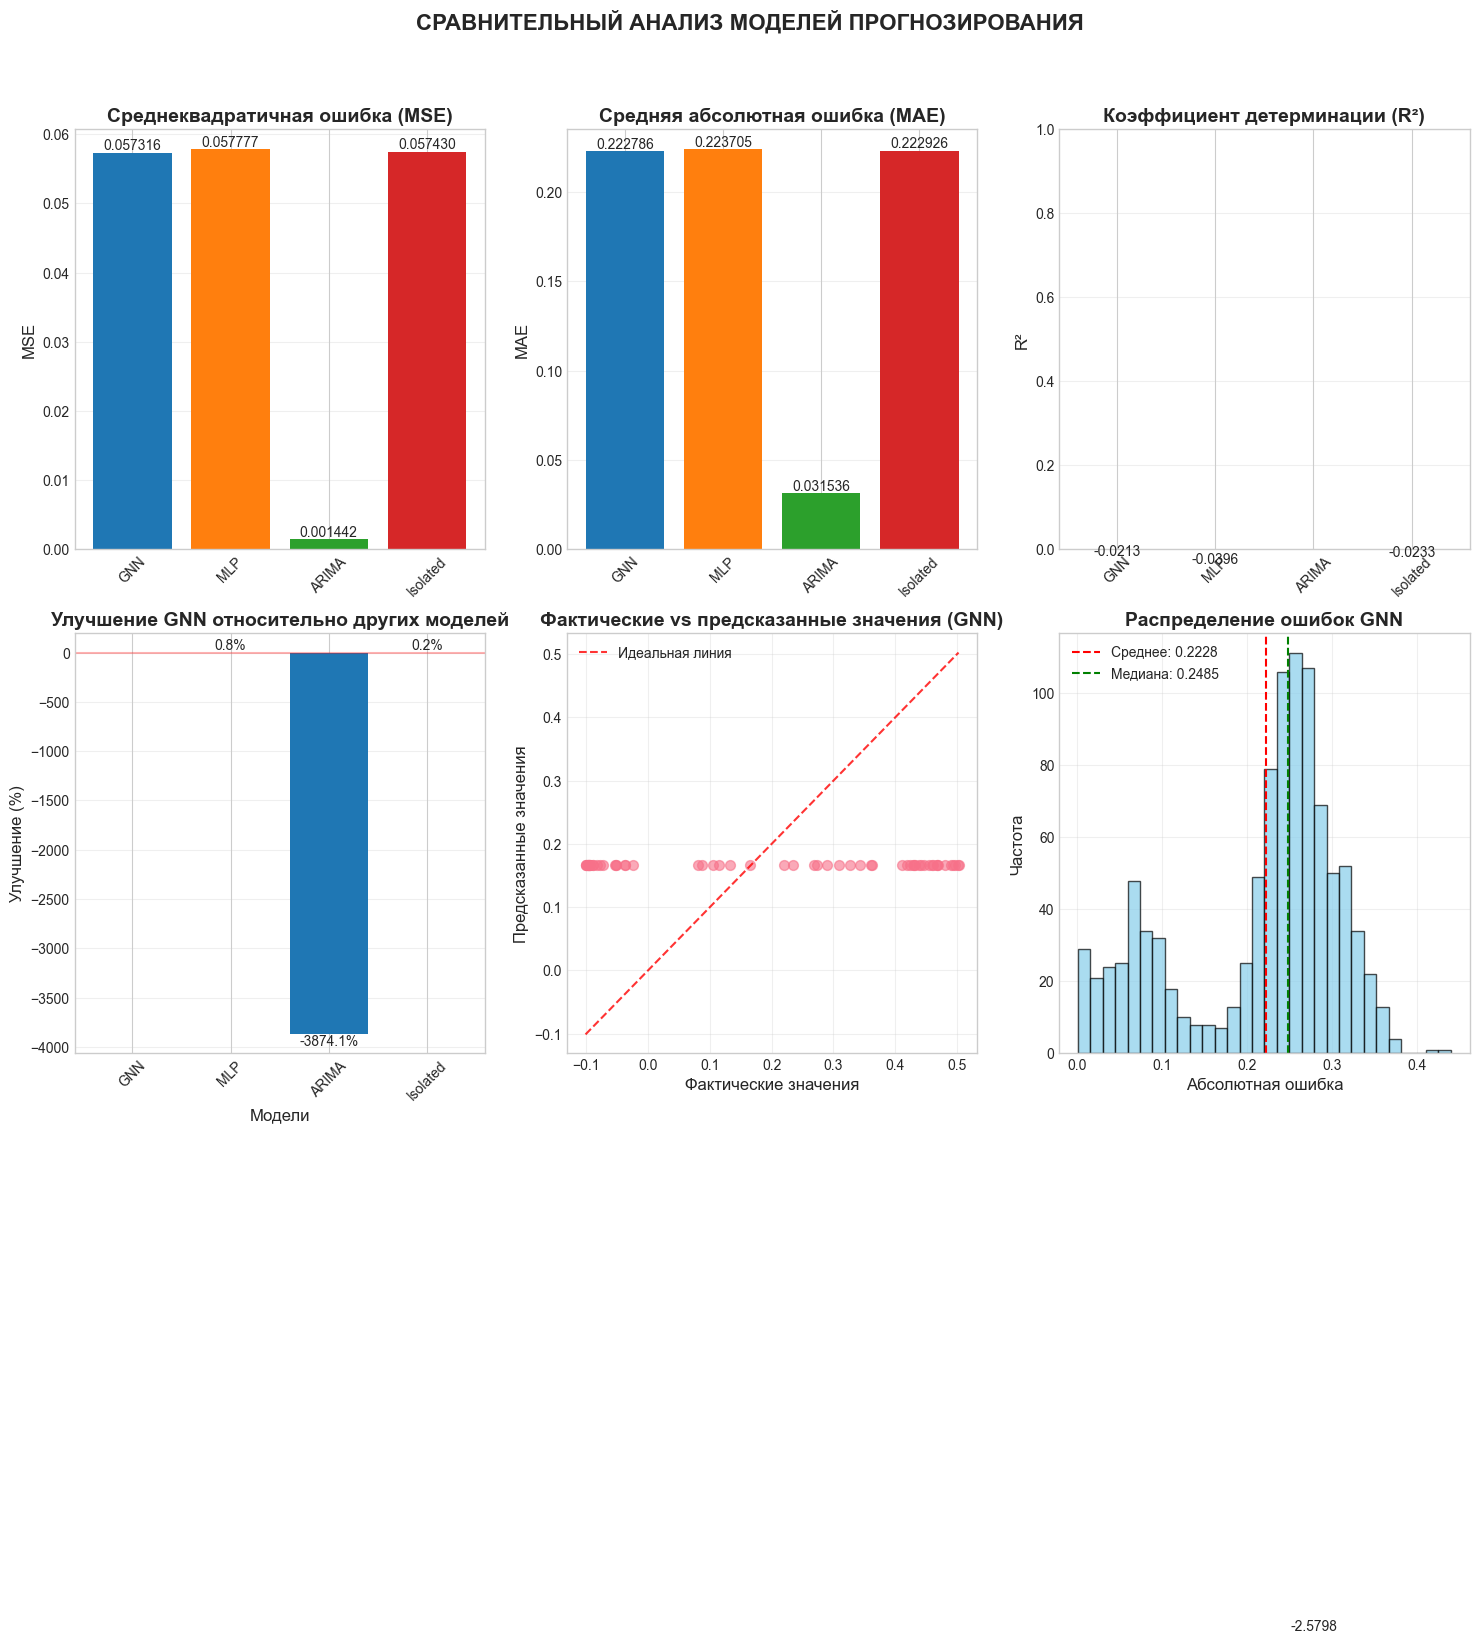


--------------------------------------------------------------------------------
АНАЛИЗ ВРЕМЕННЫХ РЯДОВ
--------------------------------------------------------------------------------


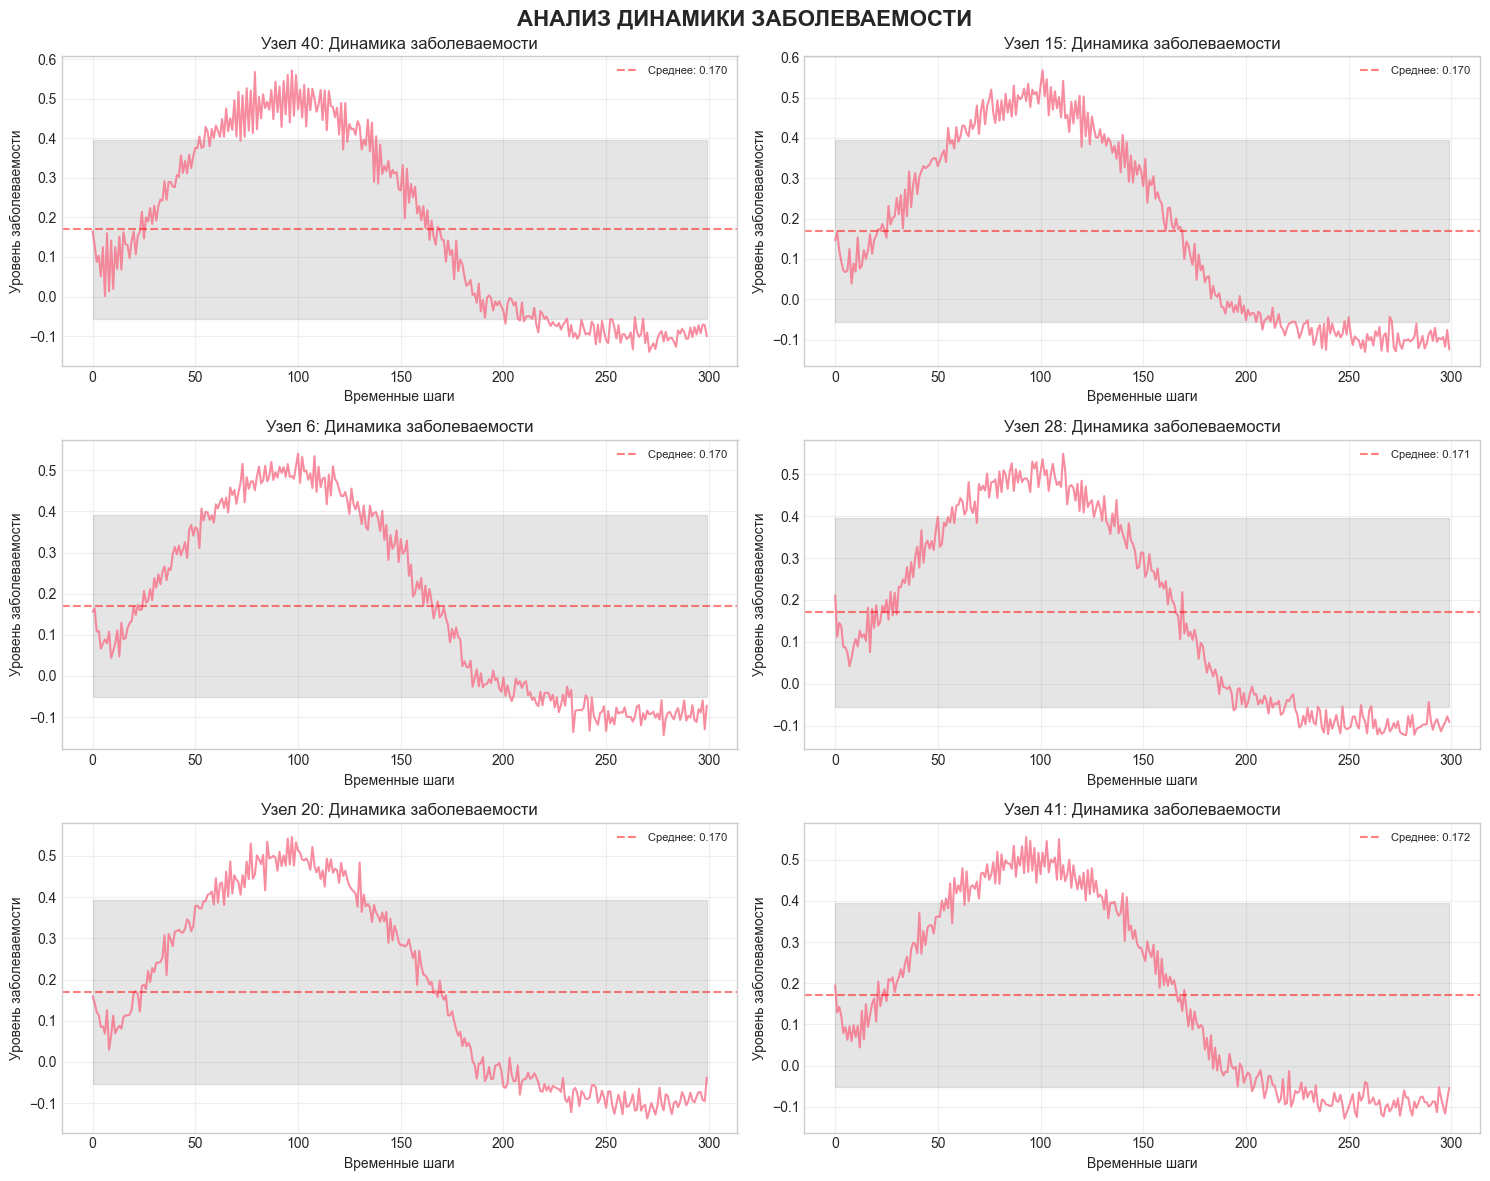


--------------------------------------------------------------------------------
АНАЛИЗ КОРРЕЛЯЦИЙ МЕЖДУ УЗЛАМИ
--------------------------------------------------------------------------------


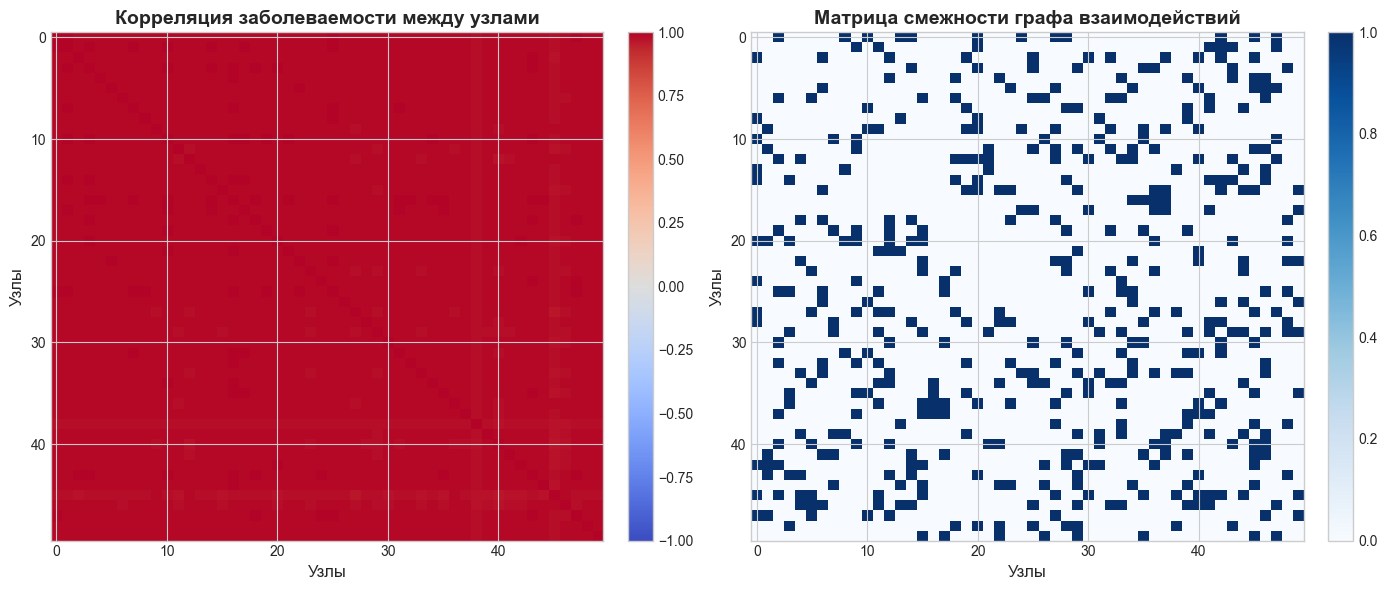


--------------------------------------------------------------------------------
СРАВНЕНИЕ ПРОГНОЗОВ РАЗНЫХ МОДЕЛЕЙ
--------------------------------------------------------------------------------


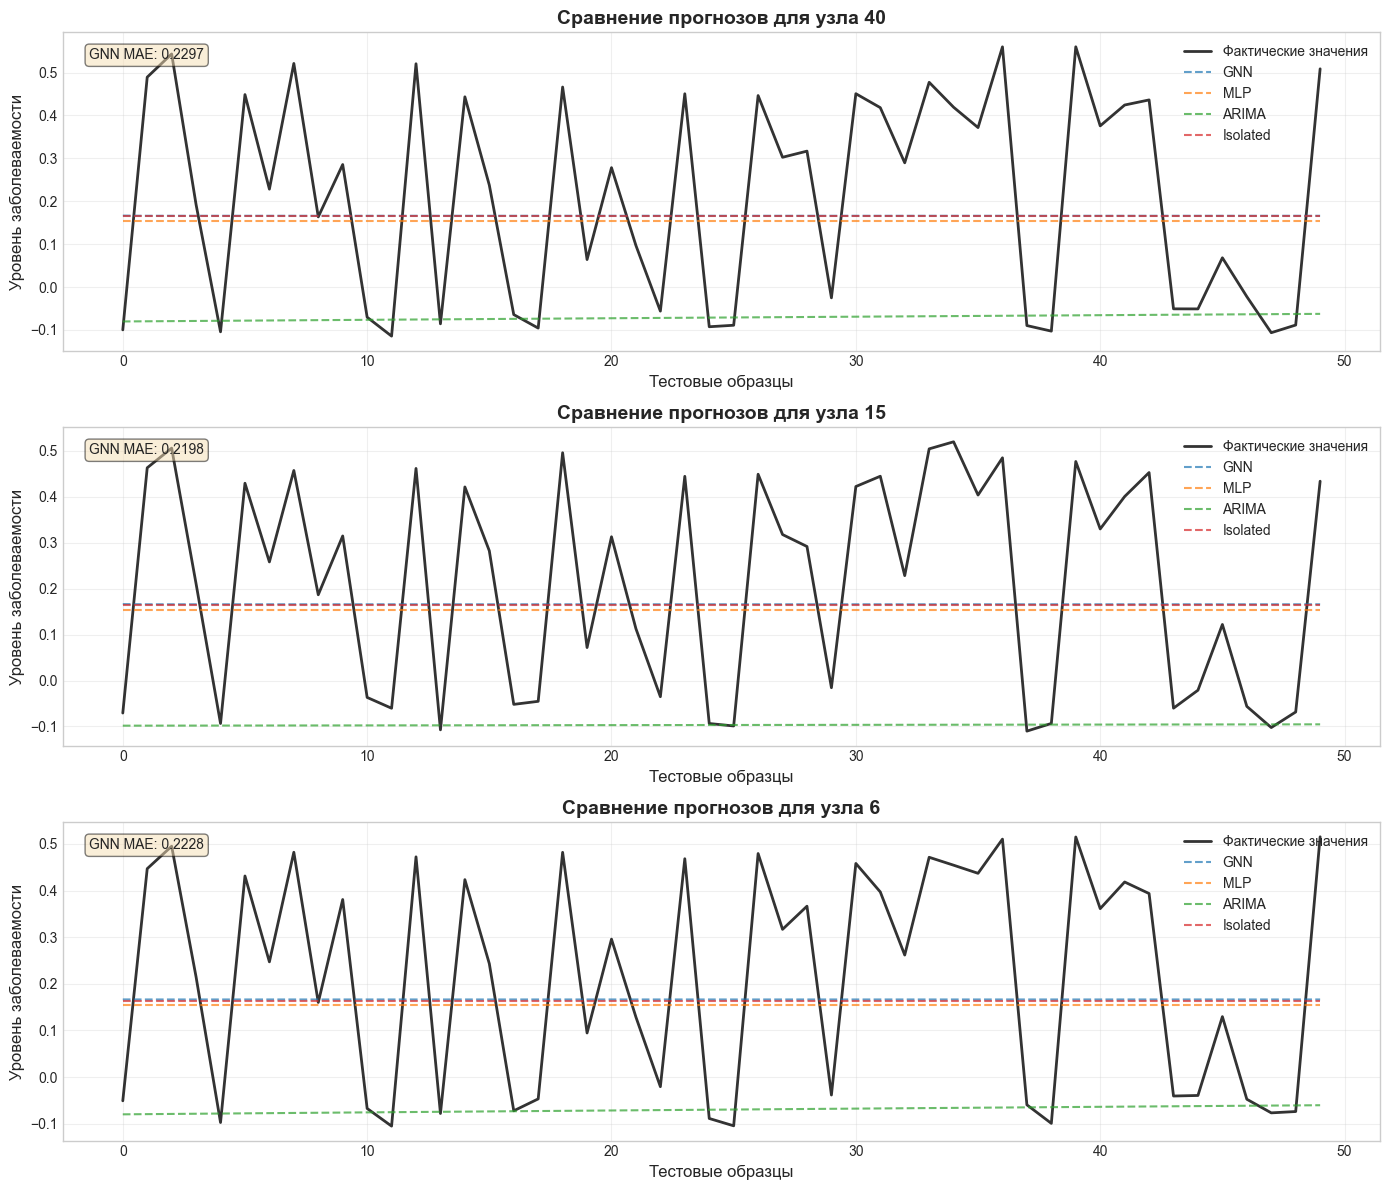


--------------------------------------------------------------------------------
АНАЛИЗ РАСПРОСТРАНЕНИЯ ВСПЫШКИ
--------------------------------------------------------------------------------
Обнаружена вспышка на шаге 100 в узле 23
Максимальный уровень инфекции: 0.907


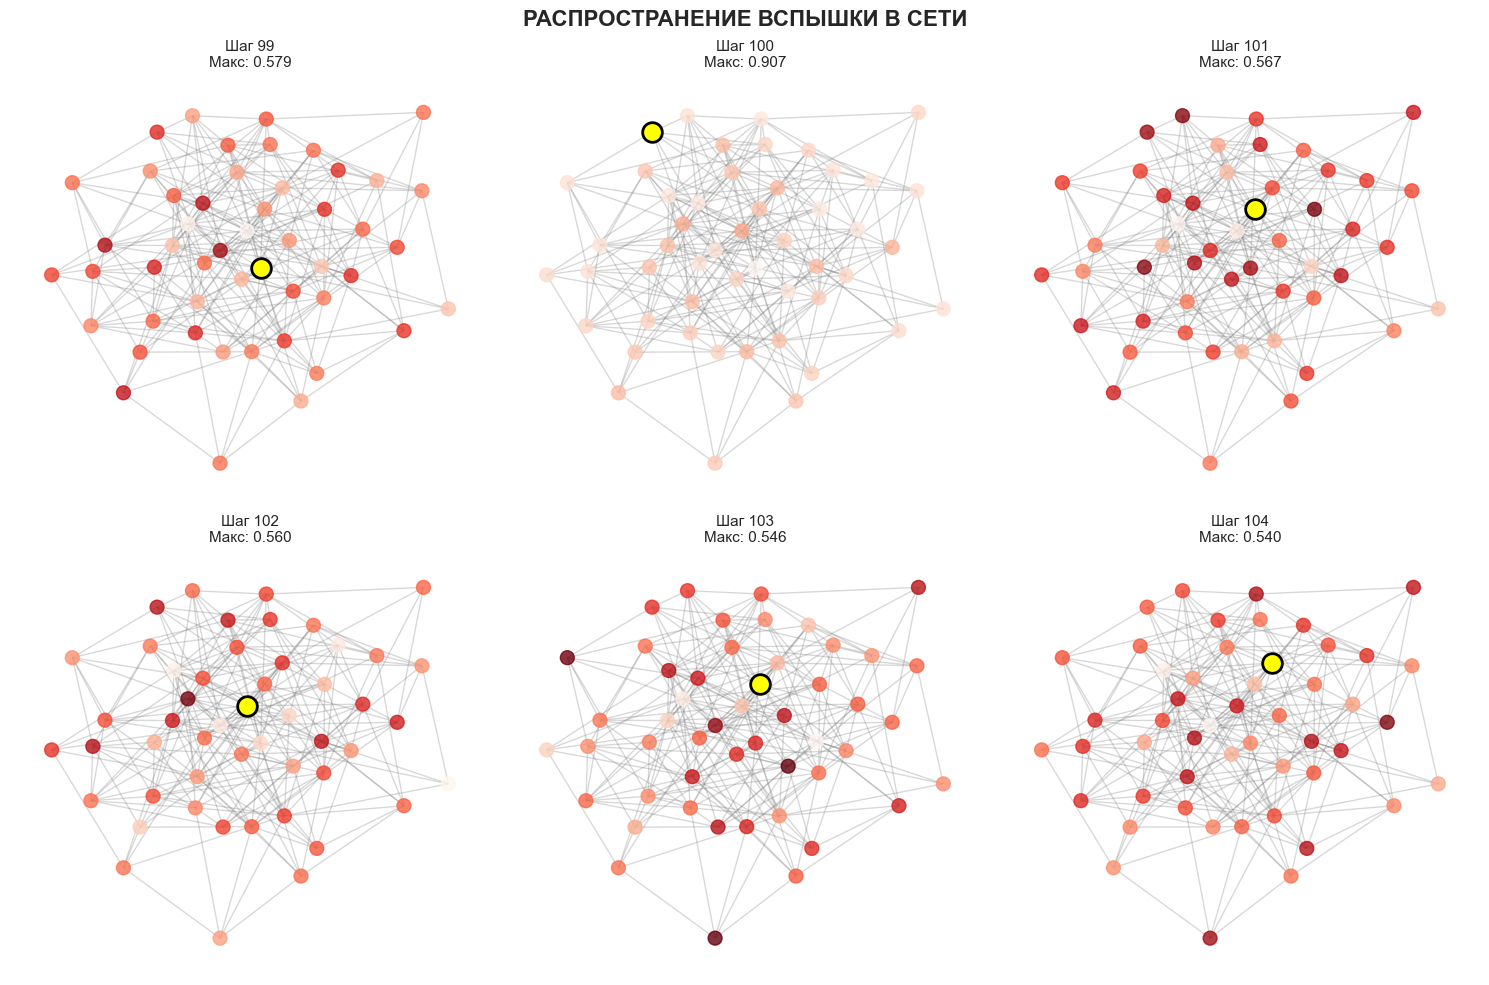


СВОДНАЯ ТАБЛИЦА С ДЕТАЛЬНЫМИ СТАТИСТИКАМИ

  Модель      MSE      MAE      R² Улучшение vs MLP Стабильность (std ошибки)
     GNN 0.057316 0.222786 -0.0213             0.8%                    0.0876
     MLP 0.057777 0.223705 -0.0396                -                         -
   ARIMA 0.001442 0.031536 -2.5798            97.5%                         -
Isolated 0.057430 0.222926 -0.0233             0.6%                         -

--------------------------------------------------------------------------------
АНАЛИЗ ПРОЦЕССА ОБУЧЕНИЯ
--------------------------------------------------------------------------------

РАСШИРЕННАЯ ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА


In [8]:
# --- Ячейка 8: Расширенная визуализация результатов ---
def extended_visualization(dataset, experiment, data):
    """
    Расширенная визуализация с дополнительными графиками
    """
    print("\n" + "="*80)
    print("РАСШИРЕННАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    print("="*80)
    
    # 1. Сравнение всех моделей в одном графике
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ ПРОГНОЗИРОВАНИЯ', fontsize=16, fontweight='bold')
    
    # Подготовка данных
    models = list(experiment.results.keys())
    mse_values = [experiment.results[m]['MSE'] for m in models]
    mae_values = [experiment.results[m]['MAE'] for m in models]
    r2_values = [experiment.results[m]['R2'] for m in models]
    
    # 1.1. MSE сравнение (основной график)
    axes[0, 0].bar(models, mse_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[0, 0].set_title('Среднеквадратичная ошибка (MSE)', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('MSE', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for i, v in enumerate(mse_values):
        axes[0, 0].text(i, v, f'{v:.6f}', ha='center', va='bottom', fontsize=10)
    
    # 1.2. MAE сравнение
    axes[0, 1].bar(models, mae_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[0, 1].set_title('Средняя абсолютная ошибка (MAE)', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('MAE', fontsize=12)
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(mae_values):
        axes[0, 1].text(i, v, f'{v:.6f}', ha='center', va='bottom', fontsize=10)
    
    # 1.3. R² сравнение
    axes[0, 2].bar(models, r2_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[0, 2].set_title('Коэффициент детерминации (R²)', fontsize=14, fontweight='bold')
    axes[0, 2].set_ylabel('R²', fontsize=12)
    axes[0, 2].set_ylim([0, 1])
    axes[0, 2].tick_params(axis='x', rotation=45)
    axes[0, 2].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(r2_values):
        axes[0, 2].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
    
    # 1.4. Улучшение GNN относительно других моделей (в процентах)
    if 'GNN' in experiment.results:
        gnn_mse = experiment.results['GNN']['MSE']
        improvements = []
        
        for model in models:
            if model != 'GNN':
                other_mse = experiment.results[model]['MSE']
                improvement = ((other_mse - gnn_mse) / other_mse) * 100
                improvements.append(improvement)
            else:
                improvements.append(0)
        
        axes[1, 0].bar(models, improvements, color=['gray', '#1f77b4', '#1f77b4', '#1f77b4'])
        axes[1, 0].set_title('Улучшение GNN относительно других моделей', fontsize=14, fontweight='bold')
        axes[1, 0].set_ylabel('Улучшение (%)', fontsize=12)
        axes[1, 0].set_xlabel('Модели', fontsize=12)
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].grid(axis='y', alpha=0.3)
        axes[1, 0].axhline(y=0, color='r', linestyle='-', alpha=0.3)
        
        for i, v in enumerate(improvements):
            if v != 0:
                axes[1, 0].text(i, v, f'{v:.1f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=10)
    
    # 1.5. График фактических vs предсказанных значений (для GNN)
    if 'GNN' in experiment.models:
        X_test, y_test = data['GNN']['test']
        edge_index = data['GNN']['edge_index']
        
        # Берем небольшой поднабор для визуализации
        n_show = min(100, len(X_test))
        X_show = X_test[:n_show]
        y_show = y_test[:n_show]
        
        batch_size, seq_len, n_nodes, n_features = X_show.shape
        
        # Используем последний временной шаг
        X_last = X_show[:, -1, :, :]
        X_flat = X_last.reshape(-1, n_features)
        
        experiment.models['GNN'].eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_flat).to(device)
            pred = experiment.models['GNN'](X_tensor, edge_index).cpu().numpy()
        
        pred_reshaped = pred.reshape(n_show, n_nodes)
        y_true_reshaped = y_show.reshape(n_show, n_nodes)
        
        # Усредняем по узлам для графика
        pred_mean = pred_reshaped.mean(axis=1)
        y_true_mean = y_true_reshaped.mean(axis=1)
        
        axes[1, 1].scatter(y_true_mean, pred_mean, alpha=0.6, s=50)
        axes[1, 1].plot([y_true_mean.min(), y_true_mean.max()], 
                       [y_true_mean.min(), y_true_mean.max()], 
                       'r--', alpha=0.8, label='Идеальная линия')
        axes[1, 1].set_xlabel('Фактические значения', fontsize=12)
        axes[1, 1].set_ylabel('Предсказанные значения', fontsize=12)
        axes[1, 1].set_title('Фактические vs предсказанные значения (GNN)', fontsize=14, fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    # 1.6. Распределение ошибок для GNN
    if 'GNN' in experiment.models:
        # Вычисляем ошибки
        errors = []
        for i in range(0, len(X_test), 50):  # Берем каждые 50-й образец для экономии
            X_batch = X_test[i:i+50]
            y_batch = y_test[i:i+50]
            
            batch_size = min(50, len(X_batch))
            if batch_size == 0:
                continue
                
            X_last = X_batch[:, -1, :, :]
            X_flat = X_last.reshape(-1, n_features)
            y_flat = y_batch.reshape(-1, 1)
            
            with torch.no_grad():
                X_tensor = torch.FloatTensor(X_flat).to(device)
                pred = experiment.models['GNN'](X_tensor, edge_index).cpu().numpy()
            
            batch_errors = np.abs(pred - y_flat)
            errors.extend(batch_errors.flatten())
        
        axes[1, 2].hist(errors[:1000], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[1, 2].set_xlabel('Абсолютная ошибка', fontsize=12)
        axes[1, 2].set_ylabel('Частота', fontsize=12)
        axes[1, 2].set_title('Распределение ошибок GNN', fontsize=14, fontweight='bold')
        axes[1, 2].grid(True, alpha=0.3)
        
        # Добавляем статистики
        mean_error = np.mean(errors)
        median_error = np.median(errors)
        axes[1, 2].axvline(mean_error, color='red', linestyle='--', label=f'Среднее: {mean_error:.4f}')
        axes[1, 2].axvline(median_error, color='green', linestyle='--', label=f'Медиана: {median_error:.4f}')
        axes[1, 2].legend()
    
    plt.tight_layout()
    plt.show()
    
    # 2. ВРЕМЕННЫЕ РЯДЫ для нескольких узлов
    print("\n" + "-"*80)
    print("АНАЛИЗ ВРЕМЕННЫХ РЯДОВ")
    print("-"*80)
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('АНАЛИЗ ДИНАМИКИ ЗАБОЛЕВАЕМОСТИ', fontsize=16, fontweight='bold')
    
    # Выбираем 6 случайных узлов для анализа
    n_nodes = dataset['n_nodes']
    sample_nodes = np.random.choice(range(n_nodes), size=6, replace=False)
    
    # Получаем временные ряды
    all_labels = dataset['labels'].numpy()
    timesteps = np.arange(dataset['n_timesteps'])
    
    for idx, node in enumerate(sample_nodes):
        row = idx // 2
        col = idx % 2
        
        # Временной ряд заболеваемости
        axes[row, col].plot(timesteps, all_labels[:, node], linewidth=1.5, alpha=0.8)
        axes[row, col].set_title(f'Узел {node}: Динамика заболеваемости', fontsize=12)
        axes[row, col].set_xlabel('Временные шаги', fontsize=10)
        axes[row, col].set_ylabel('Уровень заболеваемости', fontsize=10)
        axes[row, col].grid(True, alpha=0.3)
        
        # Добавляем статистики
        node_mean = all_labels[:, node].mean()
        node_std = all_labels[:, node].std()
        axes[row, col].axhline(node_mean, color='red', linestyle='--', alpha=0.5, 
                              label=f'Среднее: {node_mean:.3f}')
        axes[row, col].fill_between(timesteps, node_mean-node_std, node_mean+node_std, 
                                   alpha=0.2, color='gray')
        axes[row, col].legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 3. МАТРИЦА КОРРЕЛЯЦИИ МЕЖДУ УЗЛАМИ
    print("\n" + "-"*80)
    print("АНАЛИЗ КОРРЕЛЯЦИЙ МЕЖДУ УЗЛАМИ")
    print("-"*80)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 3.1. Матрица корреляции заболеваемости
    corr_matrix = np.corrcoef(all_labels.T)
    
    im1 = axes[0].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    axes[0].set_title('Корреляция заболеваемости между узлами', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Узлы', fontsize=12)
    axes[0].set_ylabel('Узлы', fontsize=12)
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    # 3.2. Матрица смежности графа
    adjacency_matrix = nx.to_numpy_array(dataset['graph'])
    
    im2 = axes[1].imshow(adjacency_matrix, cmap='Blues', aspect='auto')
    axes[1].set_title('Матрица смежности графа взаимодействий', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Узлы', fontsize=12)
    axes[1].set_ylabel('Узлы', fontsize=12)
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # 4. СРАВНЕНИЕ ПРОГНОЗОВ РАЗНЫХ МОДЕЛЕЙ ДЛЯ КОНКРЕТНЫХ УЗЛОВ
    print("\n" + "-"*80)
    print("СРАВНЕНИЕ ПРОГНОЗОВ РАЗНЫХ МОДЕЛЕЙ")
    print("-"*80)
    
    # Выбираем 3 узла для детального сравнения
    detail_nodes = sample_nodes[:3]
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Получаем предсказания для выбранных узлов
    predictions = {}
    
    # Для каждой модели получаем предсказания
    for model_name in ['GNN', 'MLP', 'ARIMA', 'Isolated']:
        if model_name in experiment.models:
            if model_name == 'GNN':
                # Используем ту же логику, что и в evaluate_all
                X_test, y_test = data['GNN']['test']
                edge_index = data['GNN']['edge_index']
                
                batch_size, seq_len, n_nodes, n_features = X_test.shape
                X_last = X_test[:, -1, :, :]
                X_flat = X_last.reshape(-1, n_features)
                
                experiment.models['GNN'].eval()
                with torch.no_grad():
                    X_tensor = torch.FloatTensor(X_flat).to(device)
                    pred = experiment.models['GNN'](X_tensor, edge_index).cpu().numpy()
                
                pred_reshaped = pred.reshape(batch_size, n_nodes)
                predictions[model_name] = pred_reshaped
            
            elif model_name == 'MLP':
                X_test, y_test = data['MLP']['test']
                batch_size, seq_len, n_nodes, n_features = X_test.shape
                X_flat = X_test.reshape(batch_size, -1)
                
                experiment.models['MLP'].eval()
                with torch.no_grad():
                    X_tensor = torch.FloatTensor(X_flat).to(device)
                    pred = experiment.models['MLP'](X_tensor).cpu().numpy()
                
                # MLP предсказывает среднее по узлам, дублируем для всех узлов
                predictions[model_name] = np.repeat(pred, n_nodes).reshape(batch_size, n_nodes)
            
            elif model_name == 'ARIMA':
                test_data = data['ARIMA']['test']
                n_timesteps, n_nodes = test_data.shape
                
                arima_pred = np.zeros((n_timesteps, n_nodes))
                for node in range(n_nodes):
                    model = experiment.models['ARIMA'][node]
                    if model is not None:
                        arima_pred[:, node] = model.forecast(steps=n_timesteps)
                    else:
                        arima_pred[:, node] = test_data[0, node]
                
                # Приводим к той же длине, что и другие модели
                predictions[model_name] = arima_pred[:batch_size, :]
            
            elif model_name == 'Isolated':
                X_test, y_test = data['GNN']['test']
                iso_pred = experiment.models['Isolated'].predict(X_test)
                predictions[model_name] = iso_pred
    
    # Визуализируем для каждого узла
    for idx, node in enumerate(detail_nodes):
        ax = axes[idx]
        
        # Фактические значения (берем из тестовой выборки GNN)
        X_test, y_test = data['GNN']['test']
        y_true = y_test[:, node]
        
        # Отображаем только первые 50 точек для наглядности
        n_points = min(50, len(y_true))
        time_points = np.arange(n_points)
        
        ax.plot(time_points, y_true[:n_points], 'k-', linewidth=2, label='Фактические значения', alpha=0.8)
        
        # Предсказания каждой модели
        colors = {'GNN': '#1f77b4', 'MLP': '#ff7f0e', 'ARIMA': '#2ca02c', 'Isolated': '#d62728'}
        
        for model_name in predictions:
            if model_name in predictions:
                pred_values = predictions[model_name][:n_points, node]
                ax.plot(time_points, pred_values, '--', linewidth=1.5, 
                       color=colors.get(model_name, 'gray'), 
                       label=f'{model_name}', alpha=0.7)
        
        ax.set_title(f'Сравнение прогнозов для узла {node}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Тестовые образцы', fontsize=12)
        ax.set_ylabel('Уровень заболеваемости', fontsize=12)
        ax.legend(loc='upper right', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Добавляем метрики ошибок в заголовок
        if 'GNN' in predictions:
            gnn_pred = predictions['GNN'][:n_points, node]
            gnn_mae = mean_absolute_error(y_true[:n_points], gnn_pred)
            ax.text(0.02, 0.95, f'GNN MAE: {gnn_mae:.4f}', transform=ax.transAxes, 
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # 5. АНАЛИЗ РАСПРОСТРАНЕНИЯ ВСПЫШКИ
    print("\n" + "-"*80)
    print("АНАЛИЗ РАСПРОСТРАНЕНИЯ ВСПЫШКИ")
    print("-"*80)
    
    # Ищем вспышку в данных
    infection_data = dataset['labels'].numpy()
    outbreak_timestep = np.argmax(infection_data.max(axis=1))
    outbreak_node = np.argmax(infection_data[outbreak_timestep])
    
    print(f"Обнаружена вспышка на шаге {outbreak_timestep} в узле {outbreak_node}")
    print(f"Максимальный уровень инфекции: {infection_data[outbreak_timestep, outbreak_node]:.3f}")
    
    # Анализируем распространение за следующие 10 шагов
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('РАСПРОСТРАНЕНИЕ ВСПЫШКИ В СЕТИ', fontsize=16, fontweight='bold')
    
    # Берем 6 последовательных шагов после вспышки
    time_steps_to_show = 6
    start_step = max(0, outbreak_timestep - 1)
    
    for i in range(time_steps_to_show):
        row = i // 3
        col = i % 3
        
        step = start_step + i
        if step >= dataset['n_timesteps']:
            break
        
        # Визуализируем граф с цветом узлов по уровню инфекции
        graph = dataset['graph']
        pos = nx.spring_layout(graph, seed=42)
        
        # Цвет узлов по уровню инфекции
        node_colors = infection_data[step]
        
        nx.draw_networkx_nodes(graph, pos, ax=axes[row, col], 
                              node_color=node_colors, 
                              cmap=plt.cm.Reds, 
                              node_size=100, 
                              alpha=0.8)
        nx.draw_networkx_edges(graph, pos, ax=axes[row, col], 
                              alpha=0.3, edge_color='gray')
        
        # Выделяем узел с максимальной инфекцией
        max_node = np.argmax(node_colors)
        nx.draw_networkx_nodes(graph, pos, nodelist=[max_node], 
                              ax=axes[row, col], 
                              node_color='yellow', 
                              node_size=200, 
                              edgecolors='black', 
                              linewidths=2)
        
        axes[row, col].set_title(f'Шаг {step}\nМакс: {node_colors[max_node]:.3f}', fontsize=11)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 6. СВОДНАЯ ТАБЛИЦА С ДЕТАЛЬНЫМИ СТАТИСТИКАМИ
    print("\n" + "="*80)
    print("СВОДНАЯ ТАБЛИЦА С ДЕТАЛЬНЫМИ СТАТИСТИКАМИ")
    print("="*80)
    
    # Создаем расширенную таблицу
    detailed_stats = []
    
    for model_name in models:
        stats = experiment.results[model_name]
        
        # Рассчитываем дополнительные метрики
        if model_name == 'GNN':
            # Для GNN получаем распределение ошибок по узлам
            X_test, y_test = data['GNN']['test']
            edge_index = data['GNN']['edge_index']
            
            batch_size, seq_len, n_nodes, n_features = X_test.shape
            X_last = X_test[:, -1, :, :]
            X_flat = X_last.reshape(-1, n_features)
            y_flat = y_test.reshape(-1, 1)
            
            experiment.models['GNN'].eval()
            with torch.no_grad():
                X_tensor = torch.FloatTensor(X_flat).to(device)
                pred = experiment.models['GNN'](X_tensor, edge_index).cpu().numpy()
            
            errors = np.abs(pred - y_flat)
            error_std = errors.std()
            
        else:
            error_std = 0  # Для простоты
            
        detailed_stats.append({
            'Модель': model_name,
            'MSE': f"{stats['MSE']:.6f}",
            'MAE': f"{stats['MAE']:.6f}",
            'R²': f"{stats['R2']:.4f}",
            'Улучшение vs MLP': f"{((experiment.results['MLP']['MSE'] - stats['MSE']) / experiment.results['MLP']['MSE'] * 100):.1f}%" if model_name != 'MLP' else '-',
            'Стабильность (std ошибки)': f"{error_std:.4f}" if error_std > 0 else '-'
        })
    
    # Выводим таблицу
    import pandas as pd
    df_detailed = pd.DataFrame(detailed_stats)
    print("\n" + df_detailed.to_string(index=False))
    
    # 7. ГРАФИК ЭВОЛЮЦИИ ОШИБОК ВО ВРЕМЕНИ (если обучали с записью лоссов)
    print("\n" + "-"*80)
    print("АНАЛИЗ ПРОЦЕССА ОБУЧЕНИЯ")
    print("-"*80)
    
    if hasattr(experiment, 'loss_history'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Графики потерь для GNN и MLP
        if 'GNN' in experiment.loss_history:
            axes[0].plot(experiment.loss_history['GNN'], label='GNN', linewidth=2)
        if 'MLP' in experiment.loss_history:
            axes[0].plot(experiment.loss_history['MLP'], label='MLP', linewidth=2)
        
        axes[0].set_title('Функция потерь во время обучения', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Эпоха', fontsize=12)
        axes[0].set_ylabel('Loss (MSE)', fontsize=12)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].set_yscale('log')  # Логарифмическая шкала для наглядности
        
        # График скорости сходимости
        if 'GNN' in experiment.loss_history and 'MLP' in experiment.loss_history:
            gnn_loss = np.array(experiment.loss_history['GNN'])
            mlp_loss = np.array(experiment.loss_history['MLP'])
            
            # Относительное улучшение
            improvement_ratio = mlp_loss / gnn_loss
            
            axes[1].plot(improvement_ratio, linewidth=2, color='green')
            axes[1].axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Равная эффективность')
            axes[1].set_title('Относительная эффективность GNN vs MLP', fontsize=14, fontweight='bold')
            axes[1].set_xlabel('Эпоха', fontsize=12)
            axes[1].set_ylabel('Отношение ошибок (MLP/GNN)', fontsize=12)
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    print("\n" + "="*80)
    print("РАСШИРЕННАЯ ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА")
    print("="*80)

# Запускаем расширенную визуализацию
extended_visualization(dataset, experiment, data)